In [6]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# 1. Define Parameters (Using Niger Delta as an example)
#Nton, M. E., & Adeyemi, M. O. (2021). Evaluation of Hydrocarbon Reserve in AD Field, Offshore Niger Delta. Open Journal of Geology, 11(5), 155-174. https://doi.org/10.4236/ojg.2021.115009
params = {
    'Vb': {'min': 5000, 'max': 40000},
    'phi': {'min': 0.19, 'max': 0.32, 'mode': 0.25},
    'Sw': {'min': 0.19, 'max': 0.39, 'mode': 0.25},
    'RF': {'min': 0.30, 'max': 0.50},
    'Bo': 1.2
}

# Number of Monte Carlo iterations
n_iterations = 10000

# 2. Generate Random Numbers
np.random.seed(23) # Set seed for reproducibility
rand_vals = np.random.rand(n_iterations)

# 3. Calculate Bulk Volume (Vb) - Truncated Normal
mean_vb = (params['Vb']['max'] + params['Vb']['min']) / 2
std_vb = (params['Vb']['max'] - params['Vb']['min']) / 6
vb = norm.ppf(rand_vals, mean_vb, std_vb) # Equivalent to NORM.INV
vb = np.clip(vb, params['Vb']['min'], params['Vb']['max']) # Equivalent to MAX(min, MIN(max, val))

# 4. Calculate Porosity (phi) - Triangular Distribution
fc_phi = (params['phi']['mode'] - params['phi']['min']) / (params['phi']['max'] - params['phi']['min'])
phi = np.where(
    rand_vals < fc_phi,
    params['phi']['min'] + np.sqrt(rand_vals * (params['phi']['mode'] - params['phi']['min']) * (params['phi']['max'] - params['phi']['min'])),
    params['phi']['max'] - np.sqrt((1 - rand_vals) * (params['phi']['max'] - params['phi']['min']) * (params['phi']['max'] - params['phi']['mode']))
)

# 5. Calculate Water Saturation (Sw) - Triangular Distribution
fc_sw = (params['Sw']['mode'] - params['Sw']['min']) / (params['Sw']['max'] - params['Sw']['min'])
sw = np.where(
    rand_vals < fc_sw,
    params['Sw']['min'] + np.sqrt(rand_vals * (params['Sw']['mode'] - params['Sw']['min']) * (params['Sw']['max'] - params['Sw']['min'])),
    params['Sw']['max'] - np.sqrt((1 - rand_vals) * (params['Sw']['max'] - params['Sw']['min']) * (params['Sw']['max'] - params['Sw']['mode']))
)

# 6. Calculate Oil Saturation (So), Bo, and RF
so = 1 - sw
bo = np.full(n_iterations, params['Bo']) # Fills array with constant 1.2

# RF - Truncated Normal
mean_rf = (params['RF']['max'] + params['RF']['min']) / 2
std_rf = (params['RF']['max'] - params['RF']['min']) / 6
rf = norm.ppf(rand_vals, mean_rf, std_rf)
rf = np.clip(rf, params['RF']['min'], params['RF']['max'])

# 7. Calculate Reserves via Volumetric Method
reserves = 7758 * vb * phi * so * rf / bo

df = pd.DataFrame({
    'Rand': rand_vals,
    'Vb': vb,
    'phi': phi,
    'Sw': sw,
    'So': so,
    'Bo': bo,
    'RF': rf,
    'RESERVE': reserves
})

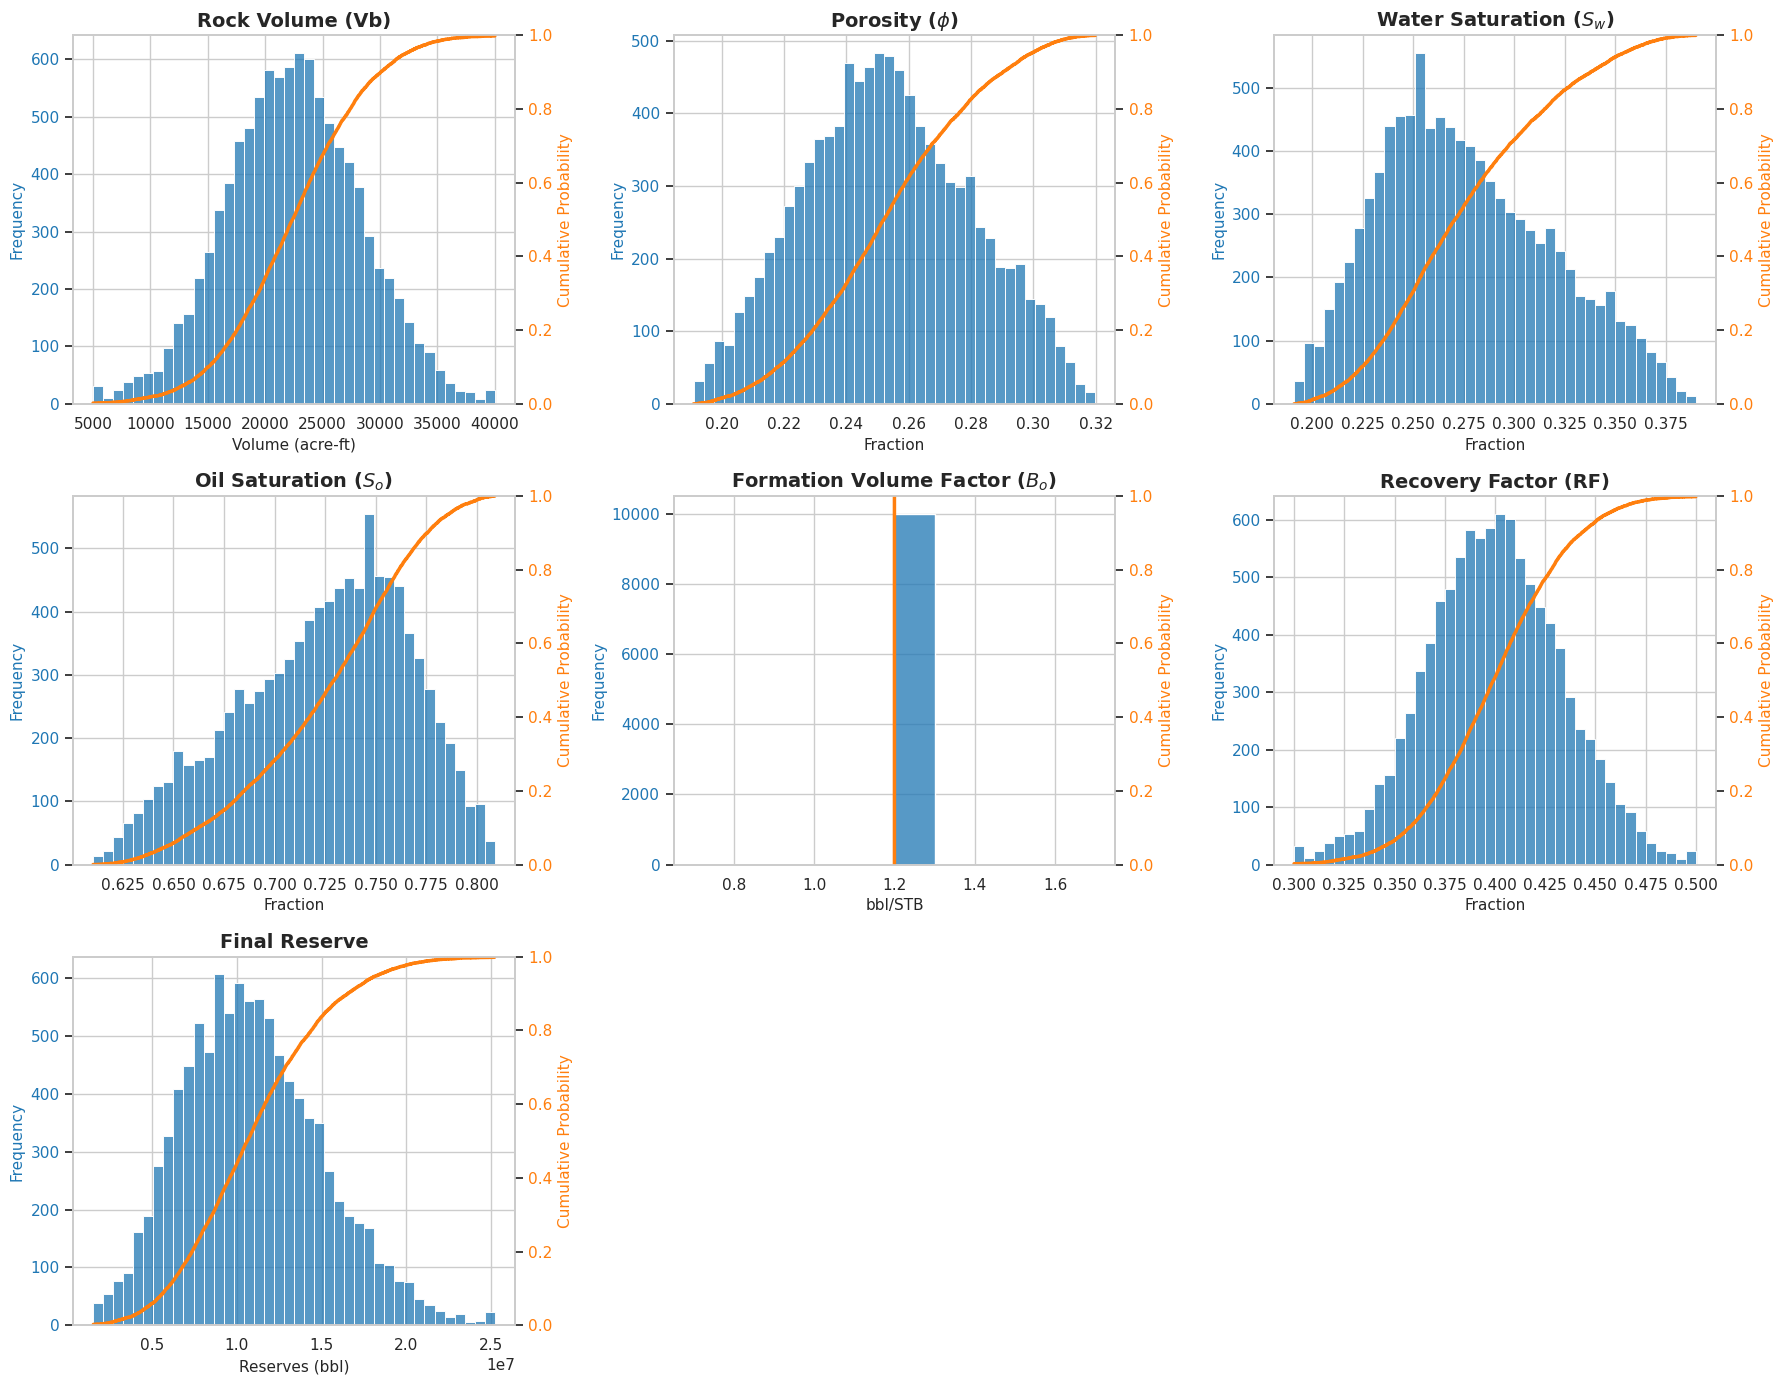

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 시각화할 7개 변수에 대한 정보 (컬럼명, 그래프 제목, X축 라벨)
plot_info = [
    {'col': 'Vb', 'title': 'Rock Volume (Vb)', 'xlabel': 'Volume (acre-ft)'},
    {'col': 'phi', 'title': 'Porosity ($\phi$)', 'xlabel': 'Fraction'},
    {'col': 'Sw', 'title': 'Water Saturation ($S_w$)', 'xlabel': 'Fraction'},
    {'col': 'So', 'title': 'Oil Saturation ($S_o$)', 'xlabel': 'Fraction'},
    {'col': 'Bo', 'title': 'Formation Volume Factor ($B_o$)', 'xlabel': 'bbl/STB'},
    {'col': 'RF', 'title': 'Recovery Factor (RF)', 'xlabel': 'Fraction'},
    {'col': 'RESERVE', 'title': 'Final Reserve', 'xlabel': 'Reserves (bbl)'}
]

# 3행 3열의 그래프 그리드 생성 (7칸만 이용)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# 각 변수별로 그래프 그리기 반복
for i, info in enumerate(plot_info):
    ax1 = axes[i]
    col = info['col']
    
    # 1. 히스토그램 (왼쪽 Y축)
    bins_count = 10 if col == 'Bo' else 40 
    sns.histplot(df[col], bins=bins_count, color="#1f77b4", edgecolor='white', ax=ax1)
    
    ax1.set_title(info['title'], fontsize=14, fontweight='bold')
    ax1.set_xlabel(info['xlabel'], fontsize=11)
    ax1.set_ylabel('Frequency', color="#1f77b4", fontsize=11)
    ax1.tick_params(axis='y', labelcolor="#1f77b4")
    
    # 2. 누적 확률 분포 CDF (오른쪽 Y축)
    ax2 = ax1.twinx()
    sns.ecdfplot(df[col], color="#ff7f0e", linewidth=2.5, ax=ax2)
    ax2.set_ylabel('Cumulative Probability', color="#ff7f0e", fontsize=11)
    ax2.tick_params(axis='y', labelcolor="#ff7f0e")
    ax2.set_ylim(0, 1.0) # 0% ~ 100% (0.0 ~ 1.0) 고정
    ax2.grid(False) # 이중 축 그리드 겹침 방지

for j in range(len(plot_info), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
p10 = df['RESERVE'].quantile(0.9)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p10_a = f"{p10:.2e}".replace("e+0", " x 10^")

print(f"The P10 reserve is estimated at {p10_a} barrels.")

The P10 reserve is estimated at 1.65 x 10^7 barrels.


In [9]:
p50 = df['RESERVE'].quantile(0.5)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p50_a = f"{p50:.2e}".replace("e+0", " x 10^")

print(f"The P50 reserve is estimated at {p50_a} barrels.")

The P50 reserve is estimated at 1.06 x 10^7 barrels.


In [10]:
p90 = df['RESERVE'].quantile(0.1)

# Format to 2 decimal places in scientific notation, then replace the 'e'
p90_a = f"{p90:.2e}".replace("e+0", " x 10^")

print(f"The P90 reserve is estimated at {p90_a} barrels.")

The P90 reserve is estimated at 5.86 x 10^6 barrels.
